In [55]:
# load results 

import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.read_csv("/Users/mariaworkman/fashion/fashion-neutrality/data/results/metrics_full_run.csv")

# keep only valid rows
metrics_df = metrics_df[metrics_df["ok"] == True]

In [56]:
# aggregate by year 

yearly = (
    metrics_df
    .groupby("year")
    .agg(
        mean_chroma=("mean_chroma", "mean"),
        neutral_share=("neutral_share", "mean"),
        count=("mean_chroma", "size")
    )
    .reset_index()
    .sort_values("year")
)

yearly.head()

,year,mean_chroma,neutral_share,count
0,2000,16.708127,0.699339,100
1,2001,16.130038,0.702347,100
2,2002,14.751548,0.741918,100
3,2003,14.293826,0.747077,100
4,2004,14.250137,0.774431,100


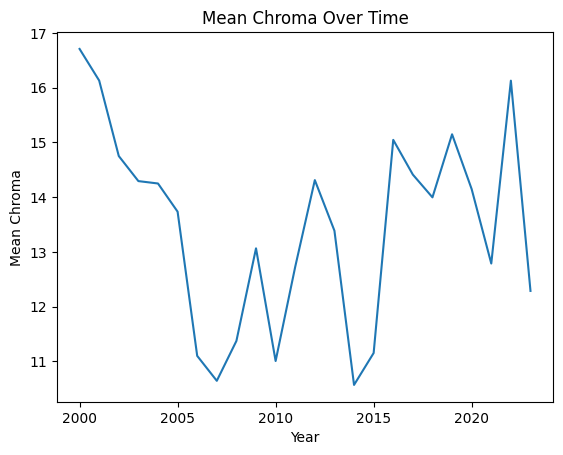

In [57]:
# plot mean chroma over years 

plt.figure()
plt.plot(yearly["year"], yearly["mean_chroma"])
plt.xlabel("Year")
plt.ylabel("Mean Chroma")
plt.title("Mean Chroma Over Time")
plt.show()


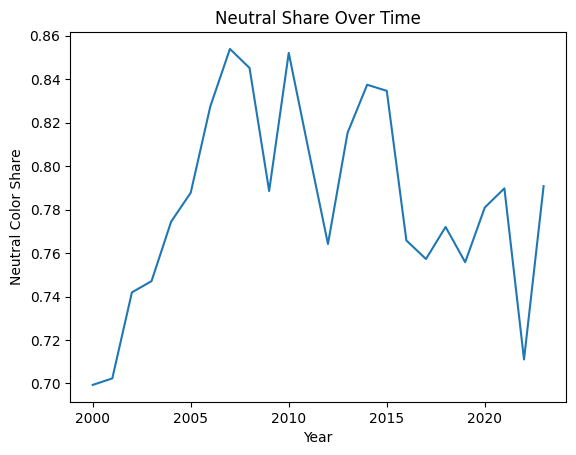

In [58]:
# plot neutral share over years (could be pretty messy, need to adjust cutoff for neutrality)

plt.figure()
plt.plot(yearly["year"], yearly["neutral_share"])
plt.xlabel("Year")
plt.ylabel("Neutral Color Share")
plt.title("Neutral Share Over Time")
plt.show()

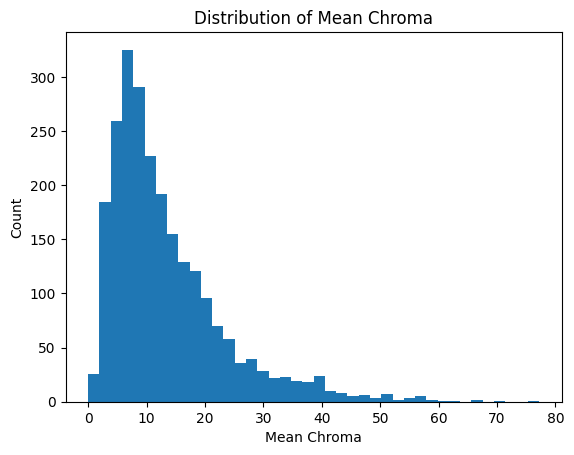

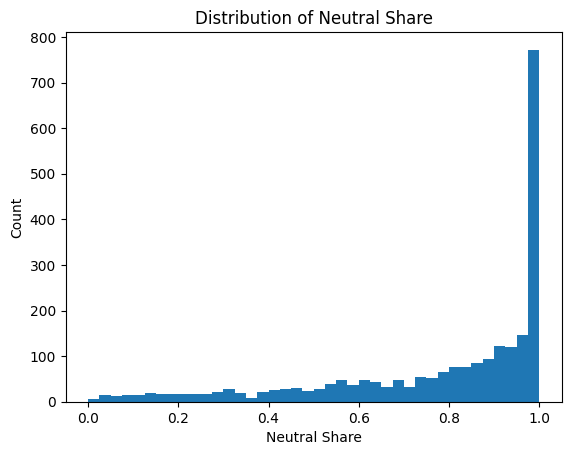

In [59]:
# distribution checks 

plt.figure()
plt.hist(metrics_df["mean_chroma"], bins=40)
plt.xlabel("Mean Chroma")
plt.ylabel("Count")
plt.title("Distribution of Mean Chroma")
plt.show()

plt.figure()
plt.hist(metrics_df["neutral_share"], bins=40)
plt.xlabel("Neutral Share")
plt.ylabel("Count")
plt.title("Distribution of Neutral Share")
plt.show()

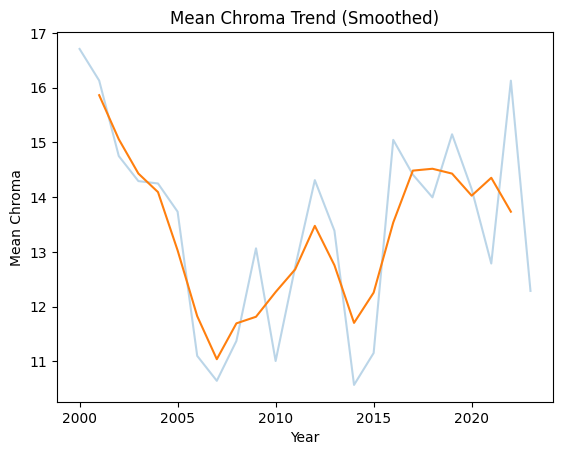

In [60]:
# smooth trend / rolling average to look cool 

yearly["chroma_smooth"] = yearly["mean_chroma"].rolling(3, center=True).mean()
yearly["neutral_smooth"] = yearly["neutral_share"].rolling(3, center=True).mean()

plt.figure()
plt.plot(yearly["year"], yearly["mean_chroma"], alpha=0.3)
plt.plot(yearly["year"], yearly["chroma_smooth"])
plt.xlabel("Year")
plt.ylabel("Mean Chroma")
plt.title("Mean Chroma Trend (Smoothed)")
plt.show()


Now a t-test to check low versus high periods and statistical significance 

In [61]:
from scipy.stats import ttest_ind

# define periods
low_period = metrics_df[metrics_df["year"].between(2006, 2009)]["mean_chroma"]
high_period = metrics_df[metrics_df["year"].between(2017, 2020)]["mean_chroma"]

# check sizes (important)
print("Low n:", len(low_period))
print("High n:", len(high_period))

# Welch’s t-test
t_stat, p_value = ttest_ind(high_period, low_period, equal_var=False)

print("\nLow period mean:", low_period.mean())
print("High period mean:", high_period.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Statistically significant difference ✅")
else:
    print("Result: Not statistically significant ❌")

Low n: 400
High n: 400

Low period mean: 11.54708463639021
High period mean: 14.426324257850647
T-statistic: 3.9091956979893054
P-value: 0.0001006348917175846
Result: Statistically significant difference ✅


Fashion data:
   year  mean_chroma  neutral_share  count  chroma_smooth  neutral_smooth
0  2000    16.708127       0.699339    100            NaN             NaN
1  2001    16.130038       0.702347    100      15.863238        0.714535
2  2002    14.751548       0.741918    100      15.058471        0.730447
3  2003    14.293826       0.747077    100      14.431837        0.754475
4  2004    14.250137       0.774431    100      14.093147        0.769759

Unemployment columns: ['observation_date', 'UNRATE']
  observation_date  UNRATE
0       1948-01-01     3.4
1       1948-02-01     3.8
2       1948-03-01     4.0
3       1948-04-01     3.9
4       1948-05-01     3.5

Yearly unemployment:
   year  unemployment_rate
0  1948           3.750000
1  1949           6.050000
2  1950           5.208333
3  1951           3.283333
4  1952           3.025000

Recession columns: ['observation_date', 'USREC']
  observation_date  USREC
0       1854-12-01      1
1       1855-01-01      0
2       1855-0

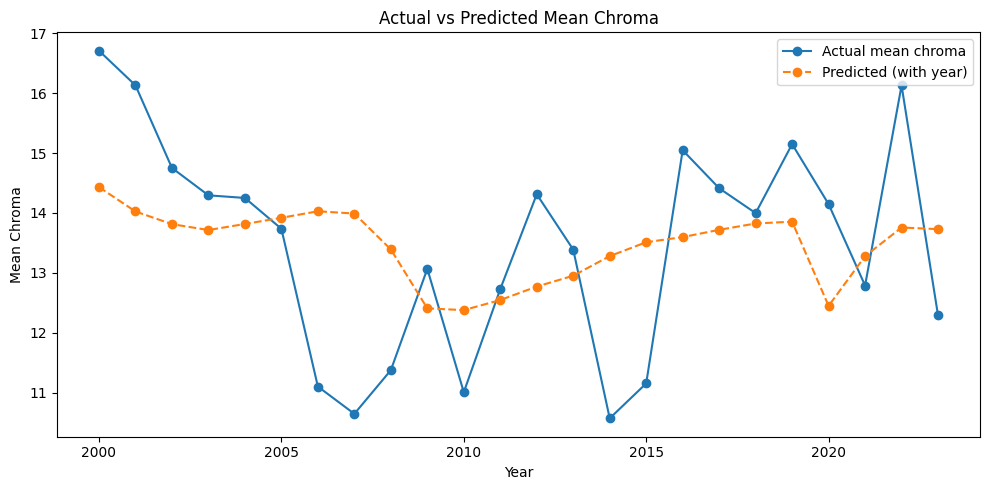

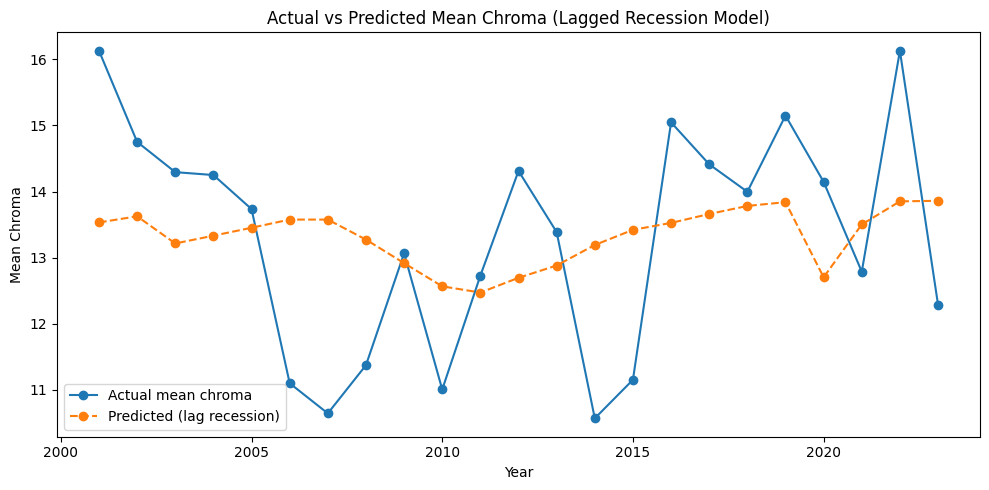

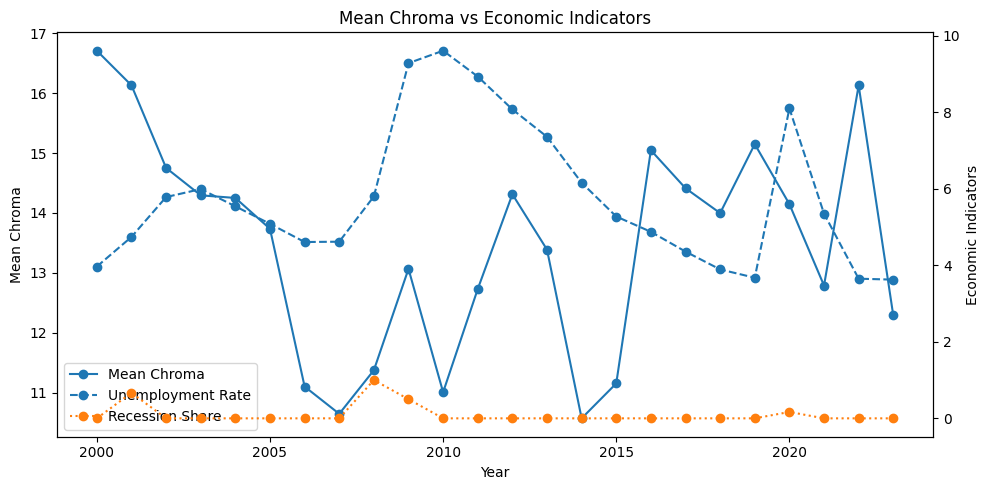

In [78]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# ----------------------------
# 1. START WITH YOUR YEARLY FASHION DATA
# ----------------------------
# Assumes you already created this:
#
# yearly = (
#     metrics_df
#     .groupby("year")
#     .agg(
#         mean_chroma=("mean_chroma", "mean"),
#         neutral_share=("neutral_share", "mean"),
#         count=("mean_chroma", "size")
#     )
#     .reset_index()
#     .sort_values("year")
# )

print("Fashion data:")
print(yearly.head())


# ----------------------------
# 2. LOAD UNEMPLOYMENT DATA FROM FRED
# ----------------------------
unemp_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE"
unemp = pd.read_csv(unemp_url)

print("\nUnemployment columns:", unemp.columns.tolist())
print(unemp.head())

# detect date column safely
unemp_date_col = None
for col in ["DATE", "date", "observation_date"]:
    if col in unemp.columns:
        unemp_date_col = col
        break

if unemp_date_col is None:
    raise ValueError("Could not find a date column in unemployment data.")

unemp["year"] = pd.to_datetime(unemp[unemp_date_col]).dt.year

# annual average unemployment rate
yearly_unemp = (
    unemp
    .groupby("year")
    .agg(unemployment_rate=("UNRATE", "mean"))
    .reset_index()
)

print("\nYearly unemployment:")
print(yearly_unemp.head())


# ----------------------------
# 3. LOAD RECESSION DATA FROM FRED
# ----------------------------
recession_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=USREC"
recession = pd.read_csv(recession_url)

print("\nRecession columns:", recession.columns.tolist())
print(recession.head())

# detect date column safely
recession_date_col = None
for col in ["DATE", "date", "observation_date"]:
    if col in recession.columns:
        recession_date_col = col
        break

if recession_date_col is None:
    raise ValueError("Could not find a date column in recession data.")

recession["year"] = pd.to_datetime(recession[recession_date_col]).dt.year

# annual recession share:
# 0 = no recession months that year
# 1 = recession all year
# values in between = partial recession year
yearly_recession = (
    recession
    .groupby("year")
    .agg(recession_share=("USREC", "mean"))
    .reset_index()
)

print("\nYearly recession share:")
print(yearly_recession.head())


# ----------------------------
# 4. MERGE ALL DATASETS
# ----------------------------
merged = (
    yearly
    .merge(yearly_unemp, on="year", how="left")
    .merge(yearly_recession, on="year", how="left")
    .sort_values("year")
)

print("\nMerged data:")
print(merged.head(10))


# ----------------------------
# 5. RESTRICT TO YEARS YOU CARE ABOUT
# ----------------------------
# Adjust this range if needed
merged = merged[(merged["year"] >= 2000) & (merged["year"] <= 2023)].copy()

# drop any missing values needed for regression
mlr_df = merged.dropna(subset=["mean_chroma", "unemployment_rate", "recession_share", "year"]).copy()

print("\nRegression-ready data:")
print(mlr_df.head())
print("\nYears in model:", mlr_df["year"].min(), "-", mlr_df["year"].max())


# ----------------------------
# 6. MULTIPLE LINEAR REGRESSION:
#    mean_chroma ~ unemployment_rate + recession_share
# ----------------------------
X = mlr_df[["unemployment_rate", "recession_share"]]
y = mlr_df["mean_chroma"]

model = LinearRegression()
model.fit(X, y)

mlr_df["pred_mean_chroma"] = model.predict(X)

print("\n--- MLR: Mean Chroma ~ Unemployment + Recession ---")
print("Intercept:", model.intercept_)
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")
print("R^2:", model.score(X, y))


# ----------------------------
# 7. OPTIONAL: INCLUDE YEAR AS A CONTROL
#    mean_chroma ~ unemployment_rate + recession_share + year
# ----------------------------
X_year = mlr_df[["unemployment_rate", "recession_share", "year"]]
y_year = mlr_df["mean_chroma"]

model_year = LinearRegression()
model_year.fit(X_year, y_year)

mlr_df["pred_mean_chroma_with_year"] = model_year.predict(X_year)

print("\n--- MLR: Mean Chroma ~ Unemployment + Recession + Year ---")
print("Intercept:", model_year.intercept_)
for feature, coef in zip(X_year.columns, model_year.coef_):
    print(f"{feature}: {coef}")
print("R^2:", model_year.score(X_year, y_year))


# ----------------------------
# 8. LAGGED RECESSION MODEL
#    Create previous year's recession variable
# ----------------------------
mlr_df["recession_lag1"] = mlr_df["recession_share"].shift(1)

lag_df = mlr_df.dropna(subset=["recession_lag1", "unemployment_rate", "mean_chroma", "year"]).copy()

X_lag = lag_df[["unemployment_rate", "recession_lag1", "year"]]
y_lag = lag_df["mean_chroma"]

model_lag = LinearRegression()
model_lag.fit(X_lag, y_lag)

lag_df["pred_mean_chroma_lag"] = model_lag.predict(X_lag)

print("\n--- Lag Model: Mean Chroma ~ Unemployment + Lagged Recession + Year ---")
print("Intercept:", model_lag.intercept_)
for feature, coef in zip(X_lag.columns, model_lag.coef_):
    print(f"{feature}: {coef}")
print("R^2:", model_lag.score(X_lag, y_lag))


# ----------------------------
# 9. OPTIONAL: LAG BOTH RECESSION AND UNEMPLOYMENT
# ----------------------------
mlr_df["unemployment_lag1"] = mlr_df["unemployment_rate"].shift(1)

lag2_df = mlr_df.dropna(subset=["unemployment_lag1", "recession_lag1", "mean_chroma", "year"]).copy()

X_lag2 = lag2_df[["unemployment_lag1", "recession_lag1", "year"]]
y_lag2 = lag2_df["mean_chroma"]

model_lag2 = LinearRegression()
model_lag2.fit(X_lag2, y_lag2)

lag2_df["pred_mean_chroma_lag2"] = model_lag2.predict(X_lag2)

print("\n--- Lag Model 2: Mean Chroma ~ Lagged Unemployment + Lagged Recession + Year ---")
print("Intercept:", model_lag2.intercept_)
for feature, coef in zip(X_lag2.columns, model_lag2.coef_):
    print(f"{feature}: {coef}")
print("R^2:", model_lag2.score(X_lag2, y_lag2))


# ----------------------------
# 10. PLOTS
# ----------------------------

# Actual vs predicted for model with year
plt.figure(figsize=(10, 5))
plt.plot(mlr_df["year"], mlr_df["mean_chroma"], marker="o", label="Actual mean chroma")
plt.plot(mlr_df["year"], mlr_df["pred_mean_chroma_with_year"], marker="o", linestyle="--", label="Predicted (with year)")
plt.xlabel("Year")
plt.ylabel("Mean Chroma")
plt.title("Actual vs Predicted Mean Chroma")
plt.legend()
plt.tight_layout()
plt.show()


# Actual vs predicted for lag recession model
plt.figure(figsize=(10, 5))
plt.plot(lag_df["year"], lag_df["mean_chroma"], marker="o", label="Actual mean chroma")
plt.plot(lag_df["year"], lag_df["pred_mean_chroma_lag"], marker="o", linestyle="--", label="Predicted (lag recession)")
plt.xlabel("Year")
plt.ylabel("Mean Chroma")
plt.title("Actual vs Predicted Mean Chroma (Lagged Recession Model)")
plt.legend()
plt.tight_layout()
plt.show()


# Plot economic series against year
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(mlr_df["year"], mlr_df["mean_chroma"], marker="o", label="Mean Chroma")
ax1.set_xlabel("Year")
ax1.set_ylabel("Mean Chroma")

ax2 = ax1.twinx()
ax2.plot(mlr_df["year"], mlr_df["unemployment_rate"], marker="o", linestyle="--", label="Unemployment Rate")
ax2.plot(mlr_df["year"], mlr_df["recession_share"], marker="o", linestyle=":", label="Recession Share")
ax2.set_ylabel("Economic Indicators")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Mean Chroma vs Economic Indicators")
plt.tight_layout()
plt.show()

In [80]:
# Drop missing values
df = merged.dropna(subset=["mean_chroma", "unemployment_rate", "year"])

# Features + target
X = df[["unemployment_rate", "year"]]
y = df["mean_chroma"]

# Fit model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

# Output
print("\n--- MLR: Mean Chroma ~ Unemployment + Year ---")
print("Intercept:", model.intercept_)
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")
print("R^2:", model.score(X, y))


--- MLR: Mean Chroma ~ Unemployment + Year ---
Intercept: 82.10249216604062
unemployment_rate: -0.3051474461022027
year: -0.03324772648901638
R^2: 0.10323950060438081


In [83]:
merged["unemp_change_lag1"] = merged["unemp_change"].shift(1)

lag_change_df = merged.dropna(subset=["chroma_change", "unemp_change_lag1"])

X_lag = lag_change_df[["unemp_change_lag1"]]
y_lag = lag_change_df["chroma_change"]

model_lag = LinearRegression()
model_lag.fit(X_lag, y_lag)

print("\n--- LAG CHANGE MODEL: ΔChroma ~ ΔUnemployment (t-1) ---")
print("Intercept:", model_lag.intercept_)
print("unemp_change_lag1:", model_lag.coef_[0])
print("R^2:", model_lag.score(X_lag, y_lag))


--- LAG CHANGE MODEL: ΔChroma ~ ΔUnemployment (t-1) ---
Intercept: -0.17902993665201647
unemp_change_lag1: -0.3055200428834013
R^2: 0.061494511743165
